<a href="https://colab.research.google.com/github/arvindkandala/deep-learning-video-inpainting-project/blob/arvind/ECE685_Video_inpainting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1

In Task I, we set up AnimateDiff as a pretrained unconditional generative prior over realistic animated video clips. AnimateDiff is a latent diffusion model built on top of Stable Diffusion 1.5, extended with a motion module — a set of temporal attention layers inserted into the U-Net that model how frames evolve over time. It was pretrained on large-scale video data and has learned a strong prior distribution over what realistic, temporally coherent video looks like.
We use AnimateDiff in this project not to generate videos from scratch, but as a prior distribution `p_θ(V)` over realistic videos. This prior will later be used in Task III to guide the conditional inpainting model — encouraging reconstructed videos to look realistic and temporally consistent, not just pixel-accurate.

What was set up:

- Loaded the SD 1.5 base model (provides the image VAE and text encoder)

- Loaded the AnimateDiff motion adapter `mm_sd_v15_v2` (provides temporal motion modeling)

- Confirmed end-to-end generation works, producing 16-frame animated clips at 512×512

- Implemented and validated `encode_video_to_latents()`, which uses the VAE encoder to map a video tensor of shape `(B, 3, T, H, W)` into AnimateDiff's latent space, producing latents of shape `(B, 4, T, H//8, W//8)`

Why the latent encoding matters:

The VAE latent space is where the prior guidance loss in Task III will operate. Given a reconstructed video from the conditional model, we encode it into this latent space and penalize its distance from what the prior would produce. This is the `L_prior` term in the combined objective `L = L_rec + λL_prior`.

### Run this cell when returning to mount drive and get to my folder

In [1]:
#This notebook is for ECE 685 Final Project
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/anime_inpainting')

Mounted at /content/drive


### Run this cell when returning to get dependencies (do this everytime)
### Restart runtime after the pip install, then remount Drive again before reloading pipeline

In [2]:
!pip install diffusers==0.24.0 huggingface_hub==0.25.0 transformers==4.38.0 accelerate==0.27.0 peft==0.9.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 436.4/436.4 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 114.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 279.7/279.7 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 131.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.25.0 which is incompatible.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.0 which is incompatible.


In [ ]:
#!git clone https://github.com/guoyww/AnimateDiff.git animatediff


In [ ]:
#!pip install -e animatediff/ -q

In [ ]:
# Downloads the pretrained weights
# Commented out so we don't redownload unnecessarily
'''
from huggingface_hub import hf_hub_download, snapshot_download
import os

os.makedirs('models/base_sd', exist_ok=True)
os.makedirs('models/motion_module', exist_ok=True)

# Downloads SD 1.5 base model
snapshot_download(
    repo_id="runwayml/stable-diffusion-v1-5",
    local_dir="models/base_sd",
    ignore_patterns=["*.msgpack", "*.bin", "flax_model*"]
)

# Downloads AnimateDiff motion module
hf_hub_download(
    repo_id="guoyww/animatediff",
    filename="mm_sd_v15_v2.ckpt",
    local_dir="models/motion_module"
)
'''

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 27 files:   0%|          | 0/27 [00:00<?, ?it/s]

mm_sd_v15_v2.ckpt:   0%|          | 0.00/1.82G [00:00<?, ?B/s]

'models/motion_module/mm_sd_v15_v2.ckpt'

### Run this cell when returning to reload pipeline

In [ ]:
from diffusers import AnimateDiffPipeline, MotionAdapter, DDIMScheduler
from diffusers.utils import export_to_gif
import torch

adapter = MotionAdapter.from_pretrained(
    "guoyww/animatediff-motion-adapter-v1-5-2",
    torch_dtype=torch.float16
)

pipeline = AnimateDiffPipeline.from_pretrained(
    "models/base_sd",
    motion_adapter=adapter,
    torch_dtype=torch.float16,
).to("cuda")

pipeline.scheduler = DDIMScheduler.from_pretrained(
    "models/base_sd",
    subfolder="scheduler",
    clip_sample=False,
    timestep_spacing="linspace",
    beta_schedule="linear",
    steps_offset=1,
)

print("Pipeline loaded successfully!")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomme

config.json:   0%|          | 0.00/455 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.82G [00:00<?, ?B/s]

The config attributes {'motion_activation_fn': 'geglu', 'motion_attention_bias': False, 'motion_cross_attention_dim': None} were passed to MotionAdapter, but are not expected and will be ignored. Please verify your config.json configuration file.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: models/base_sd/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pipeline loaded successfully!


In [ ]:
# Enable memory efficient attention to avoid OOM
pipeline.enable_attention_slicing()

# Generate a test clip
output = pipeline(
    prompt="anime scene, two characters talking, high quality, studio ghibli style",
    negative_prompt="low quality, blurry, worst quality",
    num_frames=16,
    guidance_scale=7.5,
    num_inference_steps=25,
    generator=torch.Generator("cuda").manual_seed(42),
)

# Save as gif
export_to_gif(output.frames[0], "outputs/test_generation.gif")
print("Done! Saved to outputs/test_generation.gif")

  0%|          | 0/25 [00:00<?, ?it/s]

Done! Saved to outputs/test_generation.gif


### Run this cell when returning to re-define the latent encoding function

In [ ]:
def encode_video_to_latents(pipeline, video_tensor):
    """
    Encodes a video tensor into AnimateDiff's latent space.
    video_tensor: shape (B, C, T, H, W), values in [-1, 1]
    Returns latents of shape (B, 4, T, H//8, W//8)
    """
    B, C, T, H, W = video_tensor.shape
    # Reshapes to process each frame
    frames = video_tensor.permute(0, 2, 1, 3, 4).reshape(B*T, C, H, W)
    with torch.no_grad():
        latents = pipeline.vae.encode(
            frames.to(dtype=torch.float16, device="cuda")
        ).latent_dist.sample()
        latents = latents * pipeline.vae.config.scaling_factor
    # Reshapes back to video format
    latents = latents.reshape(B, T, 4, H//8, W//8).permute(0, 2, 1, 3, 4)
    return latents

In [ ]:
import numpy as np

# Converts the generated frames to a tensor for testing
frames = output.frames[0] # list of 16 PIL images
import torchvision.transforms as T

transform = T.Compose([
    T.Resize((512, 512)),
    T.ToTensor(),           # converts to [0, 1]
    T.Normalize([0.5], [0.5])  # converts to [-1, 1]
])

frame_tensors = torch.stack([transform(f) for f in frames])  # (16, 3, 512, 512)
video_tensor = frame_tensors.unsqueeze(0).permute(0, 2, 1, 3, 4)  # (1, 3, 16, 512, 512)

latents = encode_video_to_latents(pipeline, video_tensor)
print(f"Input shape:  {video_tensor.shape}")   # expect (1, 3, 16, 512, 512)
print(f"Latent shape: {latents.shape}")     # expect (1, 4, 16, 64, 64)
print("Latent encoding works!")

Input shape:  torch.Size([1, 3, 16, 512, 512])
Latent shape: torch.Size([1, 4, 16, 64, 64])
Latent encoding works!


## Task 2

Mount + chdir

Pip install + restart

Mount + chdir again (after restart)

Extract DAVIS to /tmp/ <- new cell replaces the old verify cell

What Task II Is Actually Asking For
The project spec says to implement a conditional generative model that reconstructs masked frames. It gives two options: Conditional VAE or Conditional GAN. We are building a Conditional VAE — specifically a video inpainting model that:

- Takes a masked video as input (video with a rectangular region zeroed out)
- Learns to reconstruct what was in the missing region
- Is trained purely on reconstruction loss (no prior guidance yet — that's Task III)

Masked video clip  ──→  [Conditional Model]  ──→  Reconstructed video
- trained to minimize difference between reconstruction and original clean video

The DAVIS dataset class — provides clean video clips as ground truth. During training, we apply masks synthetically, so we always know what the correct answer is.

The mask generator — creates the rectangular masks from the project spec. The mask tells the model which pixels are missing. During training we generate a fresh random mask for every clip so the model learns to handle masks of different sizes and positions.

The conditional model (coming next) — this is the actual neural network. We're building a 3D convolutional encoder-decoder (U-Net style). The "3D" means it processes both spatial dimensions (height, width) and the temporal dimension (frames) together, so it learns that a masked region in frame 5 should be consistent with frames 4 and 6. The "conditional" part means the input is the masked video — the model's output is conditioned on what it can see.

The training loop (after that) — trains the model by minimizing the reconstruction loss

In [ ]:
import os

os.makedirs('data/DAVIS', exist_ok=True)

# Downloads DAVIS 2017 trainval set
!wget -q --show-progress -O data/DAVIS/DAVIS-2017-trainval-480p.zip \
    "https://data.vision.ee.ethz.ch/csergi/share/davis/DAVIS-2017-trainval-480p.zip"

print("Download complete!")

data/DAVIS/DAVIS-20 100%[===================>] 794.19M  22.8MB/s    in 38s     
Download complete!


In [ ]:
print(os.getcwd())
print(os.listdir('.'))

/content/drive/MyDrive/anime_inpainting
['outputs', 'animatediff', 'models', 'data']


In [ ]:
import zipfile

print("Extracting DAVIS...")
with zipfile.ZipFile('data/DAVIS/DAVIS-2017-trainval-480p.zip', 'r') as z:
    z.extractall('data/DAVIS/')

print("Extraction complete!")
print(os.listdir('data/DAVIS/DAVIS'))

Extracting DAVIS...
Extraction complete!
['Annotations', 'ImageSets', 'JPEGImages', 'README.md', 'SOURCES.md']


### Have to run this cell every session for task 2
 Extract DAVIS to /tmp/ ← new cell replaces the old verify cell

---



In [2]:
import zipfile
import os

# Always extract fresh to /tmp/ - takes ~30 seconds, always reliable
if not os.path.exists('/tmp/DAVIS/DAVIS/JPEGImages/480p'):
    print("Extracting DAVIS to local disk...")
    with zipfile.ZipFile('data/DAVIS/DAVIS-2017-trainval-480p.zip', 'r') as z:
        z.extractall('/tmp/DAVIS/')
    print("Done")
else:
    print("DAVIS already extracted this session")

sequences = sorted(os.listdir('/tmp/DAVIS/DAVIS/JPEGImages/480p'))
print(f"Total sequences: {len(sequences)}")

Extracting DAVIS to local disk...
Done
Total sequences: 90


### Have to run this cell every session for task 2


In [3]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import os
import random

class DAVISVideoDataset(Dataset):
    def __init__(self, root, num_frames=16, size=256):
        self.root = os.path.join(root, 'JPEGImages', '480p')
        self.num_frames = num_frames
        self.size = size
        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])
        self.clips = []
        sequences = sorted(os.listdir(self.root))
        for seq in sequences:
            seq_path = os.path.join(self.root, seq)
            frames = sorted([
                f for f in os.listdir(seq_path) if f.endswith('.jpg')
            ])
            for start in range(0, len(frames) - num_frames + 1, num_frames // 2):
                clip = [os.path.join(seq_path, frames[start + i])
                        for i in range(num_frames)]
                self.clips.append(clip)
        print(f"Dataset ready: {len(self.clips)} clips from {len(sequences)} sequences")

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        clip_paths = self.clips[idx]
        frames = torch.stack([
            self.transform(Image.open(p).convert('RGB'))
            for p in clip_paths
        ])
        return frames.permute(1, 0, 2, 3)

### Have to run this cell every session for task 2


In [10]:
import random
import torch

def generate_mask(T, H, W, min_coverage=0.1, max_coverage=0.4):
    """
    Generates a random rectangular binary mask for a video clip.
    Mask is consistent across all frames (same region masked every frame).

    Args:
        T: number of frames
        H: height
        W: width
        min_coverage: minimum fraction of image to mask
        max_coverage: maximum fraction of image to mask

    Returns:
        mask: tensor of shape (1, T, H, W) with 1=masked, 0=visible
    """
    min_h = int(min_coverage**0.5 * H)
    max_h = int(max_coverage**0.5 * H)
    min_w = int(min_coverage**0.5 * W)
    max_w = int(max_coverage**0.5 * W)

    mask_h = random.randint(min_h, max_h)
    mask_w = random.randint(min_w, max_w)

    cy = random.randint(mask_h // 2, H - mask_h // 2)
    cx = random.randint(mask_w // 2, W - mask_w // 2)

    mask = torch.zeros(1, T, H, W)
    mask[:, :,
         cy - mask_h//2 : cy + mask_h//2,
         cx - mask_w//2 : cx + mask_w//2] = 1.0

    return mask


# Test
T, H, W = 16, 256, 256
mask = generate_mask(T, H, W, min_coverage=0.1, max_coverage=0.4)
print(f"Mask shape: {mask.shape}")
print(f"Coverage: {mask.mean().item():.1%}")
print(f"Unique values: {mask.unique()}")
print("generate_mask defined successfully!")

Mask shape: torch.Size([1, 16, 256, 256])
Coverage: 22.3%
Unique values: tensor([0., 1.])
generate_mask defined successfully!


### Have to run this cell every session for task 2


In [11]:
import torch
import torch.nn as nn

class DoubleConv3D(nn.Module):
    """Two consecutive 3D conv layers — basic building block"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)


class VideoInpaintingUNet(nn.Module):
    """
    3D U-Net for video inpainting.
    Input:  masked video + mask concatenated = 4 channels (3 RGB + 1 mask)
    Output: reconstructed video = 3 channels (RGB)
    """
    def __init__(self, in_ch=4, base_ch=32):
        super().__init__()

        # Encoder (downsampling path)
        self.enc1 = DoubleConv3D(in_ch, base_ch)        # 4 -> 32
        self.enc2 = DoubleConv3D(base_ch, base_ch*2)    # 32 -> 64
        self.enc3 = DoubleConv3D(base_ch*2, base_ch*4)  # 64 -> 128

        self.pool = nn.MaxPool3d(kernel_size=(1,2,2), stride=(1,2,2))

        # Bottleneck
        self.bottleneck = DoubleConv3D(base_ch*4, base_ch*8)  # 128 -> 256

        # Decoder (upsampling path)
        self.up3 = nn.ConvTranspose3d(base_ch*8, base_ch*4,
                                       kernel_size=(1,2,2), stride=(1,2,2))
        self.dec3 = DoubleConv3D(base_ch*8, base_ch*4)  # 256 -> 128

        self.up2 = nn.ConvTranspose3d(base_ch*4, base_ch*2,
                                       kernel_size=(1,2,2), stride=(1,2,2))
        self.dec2 = DoubleConv3D(base_ch*4, base_ch*2)  # 128 -> 64

        self.up1 = nn.ConvTranspose3d(base_ch*2, base_ch,
                                       kernel_size=(1,2,2), stride=(1,2,2))
        self.dec1 = DoubleConv3D(base_ch*2, base_ch)    # 64 -> 32

        # Output head
        self.out_conv = nn.Conv3d(base_ch, 3, kernel_size=1)
        self.out_act = nn.Tanh()  # output in [-1, 1] to match input range

    def forward(self, x, mask):
        # x: (B, 3, T, H, W)  mask: (B, 1, T, H, W)
        inp = torch.cat([x, mask], dim=1)  # (B, 4, T, H, W)

        # Encoder
        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder with skip connections
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out_act(self.out_conv(d1))


# Test the model
model = VideoInpaintingUNet(in_ch=4, base_ch=32)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Test forward pass with dummy input
B, C, T, H, W = 1, 3, 16, 256, 256
dummy_video = torch.randn(B, C, T, H, W)
dummy_mask = torch.zeros(B, 1, T, H, W)
dummy_mask[:, :, :, 64:192, 64:192] = 1.0  # fake rectangular mask

output = model(dummy_video, dummy_mask)
print(f"Input shape:  {dummy_video.shape}")   # expect (1, 3, 16, 256, 256)
print(f"Output shape: {output.shape}")        # expect (1, 3, 16, 256, 256)
print(f"Output range: [{output.min():.2f}, {output.max():.2f}]")  # expect [-1, 1]
print("Model architecture test passed!")

Total parameters: 5,433,155
Input shape:  torch.Size([1, 3, 16, 256, 256])
Output shape: torch.Size([1, 3, 16, 256, 256])
Output range: [-0.94, 0.92]
Model architecture test passed!


### Have to run this cell every session for task 2


In [12]:
from torch.utils.data import DataLoader, random_split
import torch.optim as optim

def reconstruction_loss(pred, target, mask):
    """
    Only compute loss on masked (missing) regions.
    pred, target: (B, 3, T, H, W)
    mask: (B, 1, T, H, W) with 1=masked region
    """
    diff = torch.abs(pred - target)           # L1 loss
    masked_diff = diff * mask                 # only penalize masked pixels
    loss = masked_diff.sum() / (mask.sum() * 3 + 1e-8)  # normalize by masked area
    return loss


def train_one_epoch(model, dataloader, optimizer, device, epoch):
    model.train()
    total_loss = 0
    for batch_idx, clean_video in enumerate(dataloader):
        clean_video = clean_video.to(device)  # (B, 3, T, H, W)
        B, C, T, H, W = clean_video.shape

        # Generate random mask for this batch
        mask = torch.stack([
            generate_mask(T, H, W, min_coverage=0.1, max_coverage=0.4)
            for _ in range(B)
        ]).to(device)  # (B, 1, T, H, W)

        # Create masked input
        masked_video = clean_video * (1 - mask)  # zero out masked region

        # Forward pass
        optimizer.zero_grad()
        pred = model(masked_video, mask)

        # Compute loss only on masked region
        loss = reconstruction_loss(pred, clean_video, mask)

        # Backward pass
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 50 == 0:
            print(f"  Epoch {epoch} | Batch {batch_idx}/{len(dataloader)} "
                  f"| Loss: {loss.item():.4f}")

    return total_loss / len(dataloader)


def save_checkpoint(model, optimizer, epoch, loss, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, path)
    print(f"Checkpoint saved to {path}")


def load_checkpoint(model, optimizer, path, device):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    print(f"Loaded checkpoint from epoch {epoch}, loss {loss:.4f}")
    return epoch, loss


print("Training utilities defined successfully!")

Training utilities defined successfully!


In [13]:
import os

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create dataset and dataloader
dataset = DAVISVideoDataset('/tmp/DAVIS/DAVIS', num_frames=16, size=256)

# 90/10 train/val split
val_size = max(1, int(0.1 * len(dataset)))
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print(f"Train clips: {train_size} | Val clips: {val_size}")

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False,
                        num_workers=2, pin_memory=True)

# Model, optimizer
model = VideoInpaintingUNet(in_ch=4, base_ch=32).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Checkpoint directory
os.makedirs('outputs/checkpoints', exist_ok=True)

print("Setup complete, ready to train!")

Using device: cuda
Dataset ready: 653 clips from 90 sequences
Train clips: 588 | Val clips: 65
Setup complete, ready to train!


### Test run on 2 batches before moving on to full training

In [14]:
print("Running short test training run (2 batches)...")
model.train()

for batch_idx, clean_video in enumerate(train_loader):
    if batch_idx >= 2:
        break

    clean_video = clean_video.to(device)
    B, C, T, H, W = clean_video.shape

    mask = torch.stack([
        generate_mask(T, H, W, min_coverage=0.1, max_coverage=0.4)
        for _ in range(B)
    ]).to(device)

    masked_video = clean_video * (1 - mask)

    optimizer.zero_grad()
    pred = model(masked_video, mask)
    loss = reconstruction_loss(pred, clean_video, mask)
    loss.backward()
    optimizer.step()

    print(f"Batch {batch_idx} | Loss: {loss.item():.4f} | "
          f"Pred range: [{pred.min():.2f}, {pred.max():.2f}]")

print("Test run complete! Training loop works correctly.")

Running short test training run (2 batches)...
Batch 0 | Loss: 0.4450 | Pred range: [-0.99, 0.96]
Batch 1 | Loss: 0.4729 | Pred range: [-0.97, 0.82]
Test run complete! Training loop works correctly.


In [15]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms.functional as TF
import random
import math
from PIL import Image as PILImage
import numpy as np

# Reproducibility
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# Config
NUM_EPOCHS      = 40
BATCH_SIZE      = 2         # increase to 4 if you don't OOM
LR              = 2e-4
WARMUP_EPOCHS   = 3
GRAD_CLIP       = 1.0
NUM_FRAMES      = 16
FRAME_SIZE      = 256
MIN_COVERAGE    = 0.10
MAX_COVERAGE    = 0.40
CHECKPOINT_DIR  = 'outputs/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs('outputs', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Dataset
full_dataset = DAVISVideoDataset('/tmp/DAVIS/DAVIS', num_frames=NUM_FRAMES, size=FRAME_SIZE)
val_size     = max(1, int(0.1 * len(full_dataset)))
train_size   = len(full_dataset) - val_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size],
                                 generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"Train clips: {train_size} | Val clips: {val_size}")


# Model
model     = VideoInpaintingUNet(in_ch=4, base_ch=32).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scaler    = GradScaler()  # mixed precision

# Cosine annealing with linear warmup
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, NUM_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")


# Augmentation (applied consistently across all frames in a clip)
def augment_clip(video):
    """
    video: (3, T, H, W) in [-1, 1]
    Applies the same spatial augmentation to every frame.
    """
    # Random horizontal flip
    if random.random() > 0.5:
        video = torch.flip(video, dims=[-1])

    # Random 90° rotation (lightweight, preserves aspect ratio)
    if random.random() > 0.7:
        k = random.choice([1, 2, 3])
        video = torch.rot90(video, k=k, dims=[-2, -1])

    # Consistent brightness/contrast jitter across frames
    # (apply same factor to every frame so temporal coherence is preserved)
    brightness = random.uniform(0.8, 1.2)
    contrast   = random.uniform(0.8, 1.2)
    video = (video * contrast + (brightness - 1.0)).clamp(-1.0, 1.0)

    return video


# Loss
def composite_loss(pred, target, mask):
    """
    L1 on masked region (primary inpainting signal)  +
    0.05 * L1 on full frame (keeps unmasked region anchored, prevents drift)
    """
    # Masked L1 — only penalize the hole
    diff_masked = torch.abs(pred - target) * mask
    loss_masked = diff_masked.sum() / (mask.sum() * 3 + 1e-8)

    # Full-frame L1 — light regularizer
    loss_full   = torch.abs(pred - target).mean()

    return loss_masked + 0.05 * loss_full

# PSNR helper
def psnr(pred, target, mask):
    """PSNR computed only inside the masked region."""
    mse = ((pred - target) ** 2 * mask).sum() / (mask.sum() * 3 + 1e-8)
    if mse < 1e-10:
        return 100.0
    # pred/target are in [-1,1]; pixel range = 2
    return 10 * math.log10(4.0 / mse.item())

# Visualisation helper (saves a quick side-by-side every epoch)
def save_visual(clean, masked_video, pred, mask, epoch, idx=0, frame=0):
    def to_pil(t):
        img = (t * 0.5 + 0.5).clamp(0, 1)
        img = (img.permute(1, 2, 0).cpu().numpy() * 255).astype('uint8')
        return PILImage.fromarray(img)

    gt   = clean[idx, :, frame]          # (3, H, W)
    mv   = masked_video[idx, :, frame]
    pr   = pred[idx, :, frame]

    combined = np.concatenate([
        np.array(to_pil(gt)),
        np.array(to_pil(mv)),
        np.array(to_pil(pr))
    ], axis=1)
    PILImage.fromarray(combined).save(f'outputs/epoch_{epoch:03d}_sample.png')

# Training loop
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'val_psnr': []}

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    model.train()
    train_loss = 0.0

    for batch_idx, clean_video in enumerate(train_loader):
        clean_video = clean_video.to(device)           # (B, 3, T, H, W)
        B, C, T, H, W = clean_video.shape

        # Augment each clip in the batch independently
        aug_video = torch.stack([augment_clip(clean_video[i]) for i in range(B)])

        # Random mask — new one per batch item
        mask = torch.stack([
            generate_mask(T, H, W, MIN_COVERAGE, MAX_COVERAGE)
            for _ in range(B)
        ]).to(device)                                  # (B, 1, T, H, W)

        masked_video = aug_video * (1 - mask)

        optimizer.zero_grad()
        with autocast():                               # mixed precision forward
            pred = model(masked_video, mask)
            loss = composite_loss(pred, aug_video, mask)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        if batch_idx % 20 == 0:
            print(f"  Epoch {epoch}/{NUM_EPOCHS} | "
                  f"Batch {batch_idx}/{len(train_loader)} | "
                  f"Loss: {loss.item():.4f} | "
                  f"LR: {scheduler.get_last_lr()[0]:.2e}")

    scheduler.step()
    avg_train = train_loss / len(train_loader)

    # Validate
    model.eval()
    val_loss  = 0.0
    val_psnr_sum = 0.0

    with torch.no_grad():
        for vi, clean_video in enumerate(val_loader):
            clean_video = clean_video.to(device)
            B, C, T, H, W = clean_video.shape

            mask = torch.stack([
                generate_mask(T, H, W, MIN_COVERAGE, MAX_COVERAGE)
                for _ in range(B)
            ]).to(device)

            masked_video = clean_video * (1 - mask)

            with autocast():
                pred = model(masked_video, mask)
                loss = composite_loss(pred, clean_video, mask)

            val_loss     += loss.item()
            val_psnr_sum += psnr(pred, clean_video, mask)

            # Save a visual from the first val batch once per epoch
            if vi == 0:
                save_visual(clean_video, masked_video, pred, mask, epoch)

    avg_val   = val_loss     / len(val_loader)
    avg_psnr  = val_psnr_sum / len(val_loader)

    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)
    history['val_psnr'].append(avg_psnr)

    print(f"\nEpoch {epoch}/{NUM_EPOCHS} | "
          f"Train Loss: {avg_train:.4f} | "
          f"Val Loss: {avg_val:.4f} | "
          f"Val PSNR: {avg_psnr:.2f} dB\n")


    # Checkpoint
    # Always save latest
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'val_loss':             avg_val,
        'history':              history,
    }, f'{CHECKPOINT_DIR}/latest.pt')

    # Save best separately
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model.state_dict(),
            'val_loss':         avg_val,
            'val_psnr':         avg_psnr,
        }, f'{CHECKPOINT_DIR}/best.pt')
        print(f"  ★ New best model saved (val loss {avg_val:.4f})")

print("\n=== Training complete ===")
print(f"Best val loss: {best_val_loss:.4f}")

Device: cuda
Dataset ready: 653 clips from 90 sequences
Train clips: 588 | Val clips: 65
Model parameters: 5,433,155


/tmp/ipykernel_2240/4072692187.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()  # mixed precision
/tmp/ipykernel_2240/4072692187.py:158: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():                               # mixed precision forward


  Epoch 1/40 | Batch 0/294 | Loss: 0.4636 | LR: 6.67e-05
  Epoch 1/40 | Batch 20/294 | Loss: 0.4647 | LR: 6.67e-05
  Epoch 1/40 | Batch 40/294 | Loss: 0.4126 | LR: 6.67e-05
  Epoch 1/40 | Batch 60/294 | Loss: 0.4600 | LR: 6.67e-05
  Epoch 1/40 | Batch 80/294 | Loss: 0.3195 | LR: 6.67e-05
  Epoch 1/40 | Batch 100/294 | Loss: 0.4857 | LR: 6.67e-05
  Epoch 1/40 | Batch 120/294 | Loss: 0.2452 | LR: 6.67e-05
  Epoch 1/40 | Batch 140/294 | Loss: 0.4717 | LR: 6.67e-05
  Epoch 1/40 | Batch 160/294 | Loss: 0.4126 | LR: 6.67e-05
  Epoch 1/40 | Batch 180/294 | Loss: 0.3481 | LR: 6.67e-05
  Epoch 1/40 | Batch 200/294 | Loss: 0.2148 | LR: 6.67e-05
  Epoch 1/40 | Batch 220/294 | Loss: 0.3201 | LR: 6.67e-05
  Epoch 1/40 | Batch 240/294 | Loss: 0.3938 | LR: 6.67e-05
  Epoch 1/40 | Batch 260/294 | Loss: 0.3049 | LR: 6.67e-05
  Epoch 1/40 | Batch 280/294 | Loss: 0.2334 | LR: 6.67e-05


/tmp/ipykernel_2240/4072692187.py:196: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 1/40 | Train Loss: 0.3739 | Val Loss: 0.3181 | Val PSNR: 14.51 dB

  ★ New best model saved (val loss 0.3181)
  Epoch 2/40 | Batch 0/294 | Loss: 0.3977 | LR: 1.33e-04
  Epoch 2/40 | Batch 20/294 | Loss: 0.3898 | LR: 1.33e-04
  Epoch 2/40 | Batch 40/294 | Loss: 0.6174 | LR: 1.33e-04
  Epoch 2/40 | Batch 60/294 | Loss: 0.2574 | LR: 1.33e-04
  Epoch 2/40 | Batch 80/294 | Loss: 0.3871 | LR: 1.33e-04
  Epoch 2/40 | Batch 100/294 | Loss: 0.2263 | LR: 1.33e-04
  Epoch 2/40 | Batch 120/294 | Loss: 0.2538 | LR: 1.33e-04
  Epoch 2/40 | Batch 140/294 | Loss: 0.3282 | LR: 1.33e-04
  Epoch 2/40 | Batch 160/294 | Loss: 0.3503 | LR: 1.33e-04
  Epoch 2/40 | Batch 180/294 | Loss: 0.2737 | LR: 1.33e-04
  Epoch 2/40 | Batch 200/294 | Loss: 0.2672 | LR: 1.33e-04
  Epoch 2/40 | Batch 220/294 | Loss: 0.2749 | LR: 1.33e-04
  Epoch 2/40 | Batch 240/294 | Loss: 0.2415 | LR: 1.33e-04
  Epoch 2/40 | Batch 260/294 | Loss: 0.2178 | LR: 1.33e-04
  Epoch 2/40 | Batch 280/294 | Loss: 0.3624 | LR: 1.33e-04

Epo

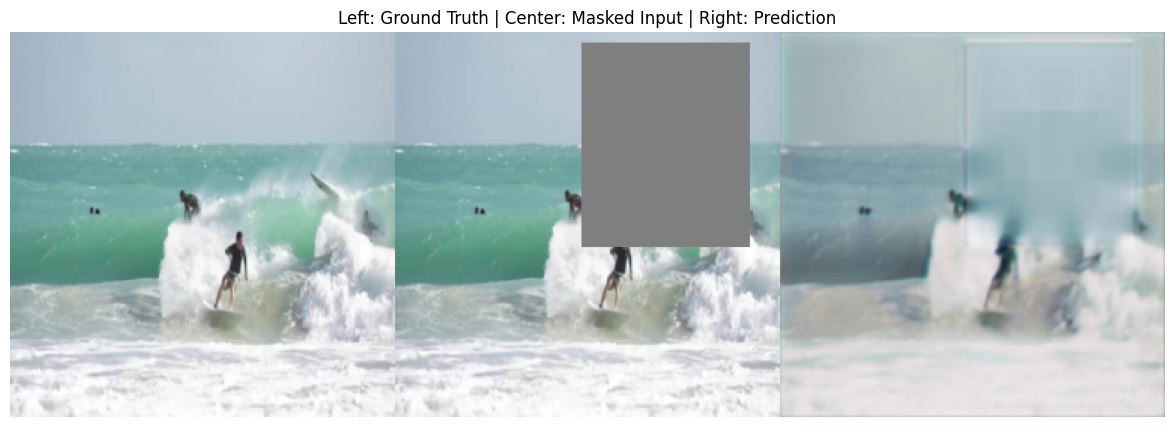

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

# Shows the last saved epoch visual (ground truth | masked | prediction side by side)
img = Image.open('outputs/epoch_040_sample.png')
plt.figure(figsize=(15, 5))
plt.imshow(img)
plt.axis('off')
plt.title('Left: Ground Truth | Center: Masked Input | Right: Prediction')
plt.show()

### Let's Begin